<a href="https://colab.research.google.com/github/adenikeadewumi/Quantum-Machine-Learning-QML-/blob/main/QML-guard%5Cqml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#QML-Guard: Adversarial Robustness of a Variational Quantum Classifier

### Research Question/Gap
Can small adversarial changes to an input fool a quantum machine-learning classifier, and can adversarial training make it more robust?

In [1]:
%pip install -q pennylane torch scikit-learn matplotlib pandas


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 70.4 MB/s eta 0:00:00


In [2]:
import pennylane as qml
import torch
import sklearn
import numpy as np
import matplotlib
import pandas as pd

print("Environment ready!")
print("PennyLane:", qml.__version__)
print("PyTorch:", torch.__version__)
print("scikit-learn:", sklearn.__version__)
print("NumPy:", np.__version__)

Environment ready!
PennyLane: 0.45.1
PyTorch: 2.11.0+cpu
scikit-learn: 1.6.1
NumPy: 2.1.3


In [3]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

# Load dataset
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset shape:", X.shape)
print("Number of classes:", len(set(y)))
print("Classes:", data.target_names)

# Put the features into a DataFrame
df = pd.DataFrame(X, columns=data.feature_names)

print("\nFirst 5 samples:")
display(df.head())

print("\nClass distribution:")
print(pd.Series(y).value_counts())

Dataset shape: (569, 30)
Number of classes: 2
Classes: ['malignant' 'benign']

First 5 samples:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Class distribution:
1    357
0    212
Name: count, dtype: int64


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Select 4 features
feature_names = [
    "mean radius",
    "mean perimeter",
    "mean area",
    "mean smoothness"
]

feature_indices = [
    list(data.feature_names).index(name)
    for name in feature_names
]

X_4 = X[:, feature_indices]

print("Selected features:")
for i, name in enumerate(feature_names):
    print(f"Qubit {i}: {name}")

print("\nNew dataset shape:", X_4.shape)


# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_4,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Standardize using ONLY the training data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nTraining samples:", len(X_train_scaled))
print("Testing samples:", len(X_test_scaled))

print("\nFirst scaled training sample:")
print(X_train_scaled[0])

Selected features:
Qubit 0: mean radius
Qubit 1: mean perimeter
Qubit 2: mean area
Qubit 3: mean smoothness

New dataset shape: (569, 4)

Training samples: 455
Testing samples: 114

First scaled training sample:
[-1.07200079 -1.0880801  -0.93927364 -0.13593988]


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Create the classical model
classical_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train
classical_model.fit(X_train_scaled, y_train)

# Predict on unseen test data
y_pred_classical = classical_model.predict(X_test_scaled)

# Evaluate
accuracy_classical = accuracy_score(y_test, y_pred_classical)

print(f"Classical baseline accuracy: {accuracy_classical:.4f}")

print("\nClassification report:")
print(
    classification_report(
        y_test,
        y_pred_classical,
        target_names=data.target_names
    )
)

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_classical))

Classical baseline accuracy: 0.8860

Classification report:
              precision    recall  f1-score   support

   malignant       0.82      0.88      0.85        42
      benign       0.93      0.89      0.91        72

    accuracy                           0.89       114
   macro avg       0.87      0.88      0.88       114
weighted avg       0.89      0.89      0.89       114

Confusion matrix:
[[37  5]
 [ 8 64]]


In [6]:
import pennylane as qml

# Number of qubits
n_qubits = 4

# Create a quantum simulator
dev = qml.device("default.qubit", wires=n_qubits)


@qml.qnode(dev)
def quantum_circuit(x):
    # Encode the 4 features into the 4 qubits
    for i in range(n_qubits):
        qml.RY(x[i], wires=i)

    # Entangle neighboring qubits
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i + 1])

    # Measure the first qubit
    return qml.expval(qml.PauliZ(0))

In [7]:
sample = X_train_scaled[0]

result = quantum_circuit(sample)

print("Input features:")
print(sample)

print("\nQuantum circuit output:")
print(result)

Input features:
[-1.07200079 -1.0880801  -0.93927364 -0.13593988]

Quantum circuit output:
0.47836817799686593


In [8]:
n_layers = 2

weight_shapes = {
    "weights": (n_layers, n_qubits, 2)
}

@qml.qnode(dev, interface="torch")
def vqc_qnode(inputs, weights):

    # Encode the input features
    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)

    # Trainable quantum layers
    for layer in range(n_layers):

        for i in range(n_qubits):
            qml.RY(weights[layer, i, 0], wires=i)
            qml.RZ(weights[layer, i, 1], wires=i)

        # Entangle neighbouring qubits
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i + 1])

    # Measure qubit 0
    return qml.expval(qml.PauliZ(0))

In [9]:
import torch
import torch.nn as nn

qlayer = qml.qnn.TorchLayer(
    vqc_qnode,
    weight_shapes
)

print(qlayer)

<Quantum Torch Layer: func=vqc_qnode>


Build the VQC classifier

In [15]:
class VQCClassifier(nn.Module):

    def __init__(self, qlayer):
        super().__init__()
        self.qlayer = qlayer

    def forward(self, x):

        # Process each sample separately
        outputs = []

        for sample in x:
            quantum_output = self.qlayer(sample)

            # Convert [-1, 1] to [0, 1]
            probability = (quantum_output + 1) / 2

            outputs.append(probability)

        return torch.stack(outputs)


vqc_model = VQCClassifier(qlayer)

print(vqc_model)

VQCClassifier(
  (qlayer): <Quantum Torch Layer: func=vqc_qnode>
)


In [16]:
X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.float32
)

print("X_train:", X_train_tensor.shape)
print("y_train:", y_train_tensor.shape)
print("X_test:", X_test_tensor.shape)
print("y_test:", y_test_tensor.shape)

X_train: torch.Size([455, 4])
y_train: torch.Size([455])
X_test: torch.Size([114, 4])
y_test: torch.Size([114])


In [17]:
loss_fn = nn.BCELoss()

optimizer = torch.optim.Adam(
    vqc_model.parameters(),
    lr=0.01
)

print("Trainable parameters:", sum(
    p.numel() for p in vqc_model.parameters()
))

Trainable parameters: 16


Train the VQC

In [18]:
id="train_vqc"
epochs = 50

loss_history = []

for epoch in range(epochs):

    optimizer.zero_grad()

    # Forward pass
    predictions = vqc_model(X_train_tensor)

    # Calculate loss
    loss = loss_fn(predictions, y_train_tensor)

    # Backpropagation
    loss.backward()

    # Update quantum parameters
    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch {epoch + 1:3d}/{epochs} "
            f"| Loss: {loss.item():.4f}"
        )

Epoch   5/50 | Loss: 0.8947
Epoch  10/50 | Loss: 0.8497
Epoch  15/50 | Loss: 0.8080
Epoch  20/50 | Loss: 0.7701
Epoch  25/50 | Loss: 0.7364
Epoch  30/50 | Loss: 0.7071
Epoch  35/50 | Loss: 0.6821
Epoch  40/50 | Loss: 0.6609
Epoch  45/50 | Loss: 0.6427
Epoch  50/50 | Loss: 0.6269


In [19]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Disable gradient calculation during evaluation
with torch.no_grad():
    vqc_probabilities = vqc_model(X_test_tensor)

# Convert probabilities to class predictions
vqc_predictions = (vqc_probabilities >= 0.5).int().numpy()

accuracy_vqc = accuracy_score(
    y_test,
    vqc_predictions
)

print(f"VQC test accuracy: {accuracy_vqc:.4f}")

print("\nClassification report:")
print(
    classification_report(
        y_test,
        vqc_predictions,
        target_names=data.target_names
    )
)

print("Confusion matrix:")
print(
    confusion_matrix(
        y_test,
        vqc_predictions
    )
)

VQC test accuracy: 0.7105

Classification report:
              precision    recall  f1-score   support

   malignant       0.80      0.29      0.42        42
      benign       0.70      0.96      0.81        72

    accuracy                           0.71       114
   macro avg       0.75      0.62      0.61       114
weighted avg       0.73      0.71      0.66       114

Confusion matrix:
[[12 30]
 [ 3 69]]


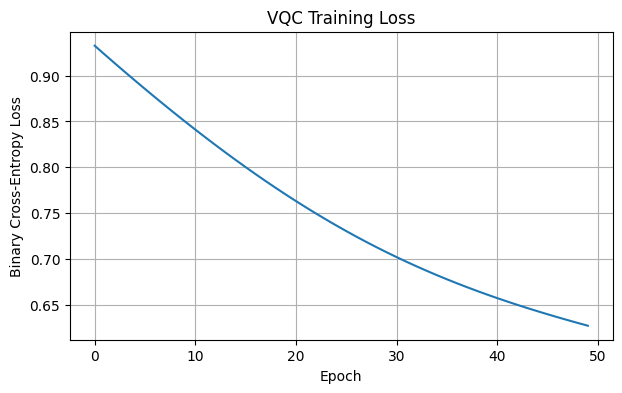

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("VQC Training Loss")
plt.grid(True)
plt.show()

Create the FGSM attack

In [22]:
def fgsm_attack(model, x, y, epsilon):

    # Make a copy so the original data is untouched
    x_adv = x.clone().detach()
    x_adv.requires_grad = True

    # Forward pass
    prediction = model(x_adv)

    # Calculate loss
    loss = loss_fn(prediction, y)

    # Gradient of loss with respect to input
    loss.backward()

    # Create adversarial perturbation
    perturbation = epsilon * x_adv.grad.sign()

    # Apply perturbation
    x_adv = x_adv + perturbation

    return x_adv.detach()

In [23]:
sample_x = X_test_tensor[0:1]
sample_y = y_test_tensor[0:1]

sample_adv = fgsm_attack(
    vqc_model,
    sample_x,
    sample_y,
    epsilon=0.05
)

print("Original input:")
print(sample_x.detach().numpy())

print("\nAdversarial input:")
print(sample_adv.numpy())

print("\nPerturbation:")
print((sample_adv - sample_x).numpy())

Original input:
[[ 1.5685128   1.7428659   1.6207637  -0.26537606]]

Adversarial input:
[[ 1.5185128   1.7928659   1.6707636  -0.31537607]]

Perturbation:
[[-0.04999995  0.04999995  0.04999995 -0.05000001]]


Attack the entire dataset

In [24]:
epsilon = 0.05

X_test_adv = fgsm_attack(
    vqc_model,
    X_test_tensor,
    y_test_tensor,
    epsilon
)

print("Original test shape:", X_test_tensor.shape)
print("Adversarial test shape:", X_test_adv.shape)

Original test shape: torch.Size([114, 4])
Adversarial test shape: torch.Size([114, 4])


In [25]:
with torch.no_grad():
    adv_probabilities = vqc_model(X_test_adv)

adv_predictions = (
    adv_probabilities >= 0.5
).int().numpy()

accuracy_adv = accuracy_score(
    y_test,
    adv_predictions
)

print(f"Clean VQC accuracy:      {accuracy_vqc:.4f}")
print(f"Adversarial accuracy:    {accuracy_adv:.4f}")
print(f"Accuracy drop:           {accuracy_vqc - accuracy_adv:.4f}")

print("\nAdversarial classification report:")
print(
    classification_report(
        y_test,
        adv_predictions,
        target_names=data.target_names
    )
)

print("Adversarial confusion matrix:")
print(
    confusion_matrix(
        y_test,
        adv_predictions
    )
)

Clean VQC accuracy:      0.7105
Adversarial accuracy:    0.6842
Accuracy drop:           0.0263

Adversarial classification report:
              precision    recall  f1-score   support

   malignant       0.69      0.26      0.38        42
      benign       0.68      0.93      0.79        72

    accuracy                           0.68       114
   macro avg       0.69      0.60      0.58       114
weighted avg       0.69      0.68      0.64       114

Adversarial confusion matrix:
[[11 31]
 [ 5 67]]


In [26]:
epsilons = [0.00, 0.01, 0.03, 0.05, 0.10, 0.15]

vqc_accuracies = []

for epsilon in epsilons:

    if epsilon == 0:
        X_adv = X_test_tensor
    else:
        X_adv = fgsm_attack(
            vqc_model,
            X_test_tensor,
            y_test_tensor,
            epsilon
        )

    with torch.no_grad():
        probabilities = vqc_model(X_adv)

    predictions = (
        probabilities >= 0.5
    ).int().numpy()

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    vqc_accuracies.append(accuracy)

    print(
        f"Epsilon = {epsilon:.2f} "
        f"| Accuracy = {accuracy:.4f}"
    )

Epsilon = 0.00 | Accuracy = 0.7105
Epsilon = 0.01 | Accuracy = 0.7105
Epsilon = 0.03 | Accuracy = 0.7018
Epsilon = 0.05 | Accuracy = 0.6842
Epsilon = 0.10 | Accuracy = 0.6667
Epsilon = 0.15 | Accuracy = 0.6579


In [27]:
# Create a fresh quantum layer
qlayer_adv = qml.qnn.TorchLayer(
    vqc_qnode,
    weight_shapes
)

# Create a fresh VQC
vqc_adv_model = VQCClassifier(
    qlayer_adv
)

# New optimizer
optimizer_adv = torch.optim.Adam(
    vqc_adv_model.parameters(),
    lr=0.01
)

print(vqc_adv_model)

print(
    "Trainable parameters:",
    sum(p.numel() for p in vqc_adv_model.parameters())
)

VQCClassifier(
  (qlayer): <Quantum Torch Layer: func=vqc_qnode>
)
Trainable parameters: 16


In [28]:
epochs_adv = 50
epsilon_train = 0.05

adv_loss_history = []

for epoch in range(epochs_adv):

    # ------------------------------------------------
    # 1. Generate adversarial training examples
    # ------------------------------------------------

    X_train_adv = fgsm_attack(
        vqc_adv_model,
        X_train_tensor,
        y_train_tensor,
        epsilon_train
    )

    # ------------------------------------------------
    # 2. Clear gradients from model parameters
    # ------------------------------------------------

    optimizer_adv.zero_grad()

    # ------------------------------------------------
    # 3. Train on adversarial examples
    # ------------------------------------------------

    predictions = vqc_adv_model(X_train_adv)

    loss = loss_fn(
        predictions,
        y_train_tensor
    )

    # ------------------------------------------------
    # 4. Backpropagation
    # ------------------------------------------------

    loss.backward()

    # ------------------------------------------------
    # 5. Update quantum parameters
    # ------------------------------------------------

    optimizer_adv.step()

    adv_loss_history.append(loss.item())

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch {epoch + 1:3d}/{epochs_adv} "
            f"| Adversarial Loss: {loss.item():.4f}"
        )

Epoch   5/50 | Adversarial Loss: 0.8751
Epoch  10/50 | Adversarial Loss: 0.8144
Epoch  15/50 | Adversarial Loss: 0.7581
Epoch  20/50 | Adversarial Loss: 0.7066
Epoch  25/50 | Adversarial Loss: 0.6601
Epoch  30/50 | Adversarial Loss: 0.6185
Epoch  35/50 | Adversarial Loss: 0.5815
Epoch  40/50 | Adversarial Loss: 0.5491
Epoch  45/50 | Adversarial Loss: 0.5212
Epoch  50/50 | Adversarial Loss: 0.4978


In [29]:
with torch.no_grad():
    adv_train_probabilities = vqc_adv_model(X_test_tensor)

adv_train_predictions = (
    adv_train_probabilities >= 0.5
).int().numpy()

accuracy_adv_train = accuracy_score(
    y_test,
    adv_train_predictions
)

print(
    f"Adversarially trained VQC "
    f"clean accuracy: {accuracy_adv_train:.4f}"
)

print("\nClassification report:")
print(
    classification_report(
        y_test,
        adv_train_predictions,
        target_names=data.target_names
    )
)

print("\nConfusion matrix:")
print(
    confusion_matrix(
        y_test,
        adv_train_predictions
    )
)

Adversarially trained VQC clean accuracy: 0.8333

Classification report:
              precision    recall  f1-score   support

   malignant       1.00      0.55      0.71        42
      benign       0.79      1.00      0.88        72

    accuracy                           0.83       114
   macro avg       0.90      0.77      0.80       114
weighted avg       0.87      0.83      0.82       114


Confusion matrix:
[[23 19]
 [ 0 72]]


In [30]:
epsilons = [0.00, 0.01, 0.03, 0.05, 0.10, 0.15]

adv_trained_accuracies = []

for epsilon in epsilons:

    if epsilon == 0:
        X_eval = X_test_tensor

    else:
        X_eval = fgsm_attack(
            vqc_adv_model,
            X_test_tensor,
            y_test_tensor,
            epsilon
        )

    with torch.no_grad():
        probabilities = vqc_adv_model(X_eval)

    predictions = (
        probabilities >= 0.5
    ).int().numpy()

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    adv_trained_accuracies.append(accuracy)

    print(
        f"Epsilon = {epsilon:.2f} | "
        f"Accuracy = {accuracy:.4f}"
    )

Epsilon = 0.00 | Accuracy = 0.8333
Epsilon = 0.01 | Accuracy = 0.8246
Epsilon = 0.03 | Accuracy = 0.8158
Epsilon = 0.05 | Accuracy = 0.8070
Epsilon = 0.10 | Accuracy = 0.7807
Epsilon = 0.15 | Accuracy = 0.7281


In [31]:
def calculate_attack_success_rate(model, X, y, epsilon):

    # Clean predictions
    with torch.no_grad():
        clean_probs = model(X)

    clean_preds = (
        clean_probs >= 0.5
    ).int().numpy()

    # Generate adversarial examples
    X_adv = fgsm_attack(
        model,
        X,
        y,
        epsilon
    )

    # Adversarial predictions
    with torch.no_grad():
        adv_probs = model(X_adv)

    adv_preds = (
        adv_probs >= 0.5
    ).int().numpy()

    # Samples correctly classified before attack
    clean_correct = clean_preds == y.numpy()

    # Samples that became incorrect after attack
    attack_success = (
        clean_correct &
        (adv_preds != y.numpy())
    )

    # Attack success rate
    asr = (
        attack_success.sum() /
        clean_correct.sum()
    )

    return asr

In [32]:
epsilon = 0.05

asr_original = calculate_attack_success_rate(
    vqc_model,
    X_test_tensor,
    y_test_tensor,
    epsilon
)

asr_defended = calculate_attack_success_rate(
    vqc_adv_model,
    X_test_tensor,
    y_test_tensor,
    epsilon
)

print(f"Original VQC ASR: {asr_original:.4f}")
print(
    f"Adversarially trained VQC ASR: "
    f"{asr_defended:.4f}"
)


Original VQC ASR: 0.0370
Adversarially trained VQC ASR: 0.0316
